In [ ]:
# workflow for county yield vs NDVI/EVI2 analysis

In [ ]:
# create county yield csvs with FIPs

In [ ]:
#!/usr/bin/env python3
# add_fips_to_yields_conowingo.py

import pandas as pd
from pathlib import Path
import os

# -------------------------------
# Paths (Conowingo)
# -------------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
YIELD_DIR = BASE / "Yield_Data"

INFILES = {
    "corn": YIELD_DIR / "yield_corn_iowa_2000_2022.csv",
    "soy":  YIELD_DIR / "yield_soy_iowa_2000_2022.csv",
}
OUTFILES = {
    "corn": YIELD_DIR / "yield_corn_iowa_2000_2022_with_fips.csv",
    "soy":  YIELD_DIR / "yield_soy_iowa_2000_2022_with_fips.csv",
}

# -------------------------------
# Helpers
# -------------------------------
def ensure_inputs_exist(infiles: dict):
    missing = [p for p in infiles.values() if not p.exists()]
    if missing:
        listing = "\n  - ".join([str(p) for p in missing])
        raise FileNotFoundError(
            "Missing input CSV(s) on Conowingo:\n"
            f"  - {listing}\n\n"
            f"Checked directory: {YIELD_DIR}"
        )

def make_fips(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build correct 5-digit county_fips from State ANSI + County ANSI.
    Coerce to numeric first, then pad (state: 2, county: 3).
    Leaves all original columns intact; appends 'county_fips'.
    """
    # Tolerate header variants (spaces/case)
    cols = {c.lower().replace(" ", ""): c for c in df.columns}
    try:
        state_col  = cols["stateansi"]
        county_col = cols["countyansi"]
    except KeyError as e:
        raise KeyError(
            "Expected columns like 'State ANSI' and 'County ANSI'. "
            f"Found columns: {list(df.columns)}"
        ) from e

    df = df.copy()

    # Force numeric (accept '15 ', '15.0', etc.)
    state_num  = pd.to_numeric(df[state_col], errors="coerce").astype("Int64")
    county_num = pd.to_numeric(df[county_col], errors="coerce").astype("Int64")

    # Basic validity check BEFORE formatting
    invalid_state  = state_num.isna() | (state_num < 0) | (state_num > 99)
    invalid_county = county_num.isna() | (county_num < 1) | (county_num > 999)
    if invalid_state.any() or invalid_county.any():
        print("[WARN] Detected invalid ANSI codes. Showing first few problematic rows:")
        print(df.loc[invalid_state | invalid_county, [state_col, county_col]].head(10))

    # Format: state 2 digits, county 3 digits (zero-padded)
    df["county_fips"] = [
        f"{int(s):02d}{int(c):03d}" if pd.notna(s) and pd.notna(c) else None
        for s, c in zip(state_num, county_num)
    ]

    # Post checks
    fips = df["county_fips"].astype(str)
    bad_len = fips.str.len() != 5
    bad_ia  = ~fips.str.startswith("19")  # Iowa sanity check (info only)

    if bad_len.any():
        print("[WARN] Some FIPS are not length 5. Sample:")
        print(df.loc[bad_len, [state_col, county_col, "county_fips"]].head(10))
    if bad_ia.any():
        print(f"[INFO] Rows not starting with '19' (Iowa): {int(bad_ia.sum())}")

    # Sanity examples
    ex1 = df[(state_num == 19) & (county_num == 15)].head(1)
    ex2 = df[(state_num == 19) & (county_num == 127)].head(1)
    if not ex1.empty:
        print(f"Example: state=19, county=15 → {ex1.iloc[0]['county_fips']} (expected 19015)")
    if not ex2.empty:
        print(f"Example: state=19, county=127 → {ex2.iloc[0]['county_fips']} (expected 19127)")

    return df

# -------------------------------
# Process and save (to Conowingo)
# -------------------------------
def main():
    ensure_inputs_exist(INFILES)
    # Ensure output folder exists (should already, but just in case)
    YIELD_DIR.mkdir(parents=True, exist_ok=True)

    for crop, inpath in INFILES.items():
        print(f"[INFO] Reading {crop}: {inpath}")
        df_raw = pd.read_csv(inpath)
        df_out = make_fips(df_raw)
        outpath = OUTFILES[crop]
        df_out.to_csv(outpath, index=False)
        print(f"[OK] Wrote: {outpath}\n")

if __name__ == "__main__":
    main()


In [ ]:
# aggregate EVI2 and NDVI by county and crop

In [4]:
#!/usr/bin/env python3
"""
Summarize NDVI + EVI2 by Iowa county and crop (corn/soybeans) for a given month.

Inputs (based on your project layout):
- Reference grid: /CropMasks/2016/CDL_2016_corn_mask_uint8.tif
- County boundaries: /Shapefiles/cb_2018_us_county_500k/cb_2018_us_county_500k.shp (filter Iowa)
- Monthly MAX mosaics:
    /NDVI/<year>/<year>_<month>_MAX/NDVI_<year>_<month>_MAX_MOSAIC.tif
    /NDVI/<year>/<year>_<month>_MAX/EVI2_<year>_<month>_MAX_MOSAIC.tif
- Annual crop masks (uint8; 1=crop, 0=not crop):
    /CropMasks/<year>/CDL_<year>_corn_mask_uint8.tif
    /CropMasks/<year>/CDL_<year>_soy_mask_uint8.tif

Outputs:
- /analysis/vi_by_county_crop_<month>/vi_by_county_crop_<month>_<year>.csv
- /analysis/vi_by_county_crop_<month>/vi_by_county_crop_<month>_ALL.csv
"""

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import os

# -----------------------------
# USER SETTINGS
# -----------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

MONTH = "07"                       # "05".."10" etc.
YEARS = list(range(2024, 2025))    # adjust as needed

# Canonical grid anchor: 2016 CDL crop mask (used for all years)
REF_RASTER = BASE / "CropMasks" / "2016" / "CDL_2016_corn_mask_uint8.tif"

# County polygons (nationwide; we will filter Iowa)
COUNTIES_SHP = BASE / "Shapefiles" / "cb_2018_us_county_500k" / "cb_2018_us_county_500k.shp"
COUNTY_FIPS_FIELD = "GEOID"   # 5-digit county FIPS in this Census file
STATEFP_FIELD = "STATEFP"     # state FIPS (string)
IOWA_STATEFP = "19"

# Output directory
OUT_DIR = BASE / "analysis" / f"vi_by_county_crop_{MONTH}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# PATH HELPERS (match your naming)
# -----------------------------
def ndvi_mosaic(year: int) -> Path:
    return BASE / "NDVI" / str(year) / f"{year}_{MONTH}_MAX" / f"NDVI_{year}_{MONTH}_MAX_MOSAIC.tif"

def evi2_mosaic(year: int) -> Path:
    return BASE / "NDVI" / str(year) / f"{year}_{MONTH}_MAX" / f"EVI2_{year}_{MONTH}_MAX_MOSAIC.tif"

def crop_mask(year: int, crop: str) -> Path:
    # crop = "corn" or "soybeans"
    if crop == "corn":
        return BASE / "CropMasks" / str(year) / f"CDL_{year}_corn_mask_uint8.tif"
    elif crop == "soybeans":
        return BASE / "CropMasks" / str(year) / f"CDL_{year}_soy_mask_uint8.tif"
    else:
        raise ValueError(f"Unknown crop: {crop}")

# -----------------------------
# CORE UTILITIES
# -----------------------------
def read_ref_grid(ref_path: Path):
    if not ref_path.exists():
        raise FileNotFoundError(f"Reference raster not found: {ref_path}")
    with rasterio.open(ref_path) as ref:
        return {
            "crs": ref.crs,
            "transform": ref.transform,
            "width": ref.width,
            "height": ref.height,
        }

def assert_same_grid(ref, raster_path: Path):
    with rasterio.open(raster_path) as src:
        if src.crs != ref["crs"]:
            raise ValueError(f"CRS mismatch for {raster_path}\n  src: {src.crs}\n  ref: {ref['crs']}")
        if src.transform != ref["transform"]:
            raise ValueError(f"Transform/alignment mismatch for {raster_path}")
        if src.width != ref["width"] or src.height != ref["height"]:
            raise ValueError(f"Shape mismatch for {raster_path}\n  src: ({src.height},{src.width})\n  ref: ({ref['height']},{ref['width']})")

def open_array(path: Path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata
    return arr, nodata

def rasterize_iowa_counties(ref, counties_shp: Path, fips_field: str):
    gdf = gpd.read_file(counties_shp)

    # filter Iowa
    if STATEFP_FIELD not in gdf.columns:
        raise KeyError(f"Expected '{STATEFP_FIELD}' in county shapefile. Columns: {list(gdf.columns)}")
    gdf = gdf[gdf[STATEFP_FIELD].astype(str) == IOWA_STATEFP].copy()

    if gdf.empty:
        raise ValueError("Iowa county filter produced 0 features. Check STATEFP field and values.")

    # ensure fips field exists
    if fips_field not in gdf.columns:
        raise KeyError(f"Expected '{fips_field}' in county shapefile. Columns: {list(gdf.columns)}")

    # project to ref CRS
    gdf = gdf.to_crs(ref["crs"])

    # fix any invalid geometries
    gdf["geometry"] = gdf["geometry"].buffer(0)

    # normalize FIPS as 5-digit strings
    gdf[fips_field] = gdf[fips_field].astype(str).str.zfill(5)

    # map each county to an integer code for fast bincount
    fips_unique = sorted(gdf[fips_field].unique())
    fips_to_code = {f: i + 1 for i, f in enumerate(fips_unique)}  # 1..N
    code_to_fips = {v: k for k, v in fips_to_code.items()}
    gdf["code"] = gdf[fips_field].map(fips_to_code).astype(np.int32)

    shapes = ((geom, code) for geom, code in zip(gdf.geometry, gdf["code"]))
    county_code = rasterize(
        shapes=shapes,
        out_shape=(ref["height"], ref["width"]),
        transform=ref["transform"],
        fill=0,
        dtype="int32",
        all_touched=False,
    )

    return county_code, code_to_fips

def mean_by_county(county_code: np.ndarray, values: np.ndarray, valid_mask: np.ndarray):
    cc = county_code[valid_mask]
    vv = values[valid_mask]

    sums = np.bincount(cc, weights=vv)
    counts = np.bincount(cc)

    with np.errstate(divide="ignore", invalid="ignore"):
        means = sums / counts

    return means, counts

# -----------------------------
# MAIN
# -----------------------------
def main():
    ref = read_ref_grid(REF_RASTER)

    # Precompute county raster on the reference grid
    county_code, code_to_fips = rasterize_iowa_counties(ref, COUNTIES_SHP, COUNTY_FIPS_FIELD)
    in_county = county_code > 0

    all_rows = []

    for year in YEARS:
        ndvi_path = ndvi_mosaic(year)
        evi2_path = evi2_mosaic(year)

        if not ndvi_path.exists():
            print(f"[SKIP] Missing NDVI mosaic: {ndvi_path}")
            continue

        # Enforce alignment
        assert_same_grid(ref, ndvi_path)
        if evi2_path.exists():
            assert_same_grid(ref, evi2_path)
        else:
            print(f"[WARN] Missing EVI2 mosaic: {evi2_path}")

        ndvi, ndvi_nodata = open_array(ndvi_path)
        evi2, evi2_nodata = (None, None)
        if evi2_path.exists():
            evi2, evi2_nodata = open_array(evi2_path)

        # NDVI validity
        ndvi = ndvi.astype("float32")
        ndvi_valid = np.isfinite(ndvi)
        if ndvi_nodata is not None:
            ndvi_valid &= (ndvi != ndvi_nodata)
        ndvi = np.clip(ndvi, -1, 1)

        # EVI2 validity
        if evi2 is not None:
            evi2 = evi2.astype("float32")
            evi2_valid = np.isfinite(evi2)
            if evi2_nodata is not None:
                evi2_valid &= (evi2 != evi2_nodata)
            evi2 = np.clip(evi2, -1, 1)

        for crop in ["corn", "soybeans"]:
            mask_path = crop_mask(year, crop)
            if not mask_path.exists():
                print(f"[SKIP] Missing crop mask ({crop}): {mask_path}")
                continue

            assert_same_grid(ref, mask_path)

            m, m_nodata = open_array(mask_path)
            # crop pixels are 1; treat anything else as non-crop
            crop_pixels = (m == 1)

            # NDVI zonal mean
            valid_ndvi = in_county & crop_pixels & ndvi_valid
            ndvi_means, ndvi_counts = mean_by_county(county_code, ndvi, valid_ndvi)

            # EVI2 zonal mean (optional)
            if evi2 is not None:
                valid_evi2 = in_county & crop_pixels & evi2_valid
                evi2_means, evi2_counts = mean_by_county(county_code, evi2, valid_evi2)
            else:
                evi2_means, evi2_counts = None, None

            # emit rows for counties with any NDVI pixels
            for code in range(1, len(ndvi_counts)):
                n = int(ndvi_counts[code]) if code < len(ndvi_counts) else 0
                if n == 0:
                    continue

                row = {
                    "year": year,
                    "month": int(MONTH),
                    "crop": crop,
                    "county_fips": code_to_fips.get(code),
                    "n_pixels_ndvi": n,
                    "mean_ndvi": float(ndvi_means[code]),
                }

                if evi2_means is not None and code < len(evi2_means):
                    ne = int(evi2_counts[code]) if evi2_counts is not None and code < len(evi2_counts) else 0
                    row["n_pixels_evi2"] = ne
                    row["mean_evi2"] = float(evi2_means[code]) if ne > 0 else np.nan

                all_rows.append(row)

        # per-year write (helps QC and partial reruns)
        df_year = pd.DataFrame([r for r in all_rows if r["year"] == year])
        if not df_year.empty:
            out_year = OUT_DIR / f"vi_by_county_crop_{MONTH}_{year}.csv"
            df_year.to_csv(out_year, index=False)
            print(f"[OK] Wrote {out_year}")

    df_all = pd.DataFrame(all_rows)

    # Ensure types are merge-friendly
    if not df_all.empty:
        df_all["county_fips"] = df_all["county_fips"].astype(str).str.zfill(5)
        df_all["year"] = df_all["year"].astype("Int64")

    out_all = OUT_DIR / f"vi_by_county_crop_{MONTH}_ALL.csv"
    df_all.to_csv(out_all, index=False)
    print(f"[OK] Wrote {out_all}")

if __name__ == "__main__":
    main()


[OK] Wrote /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_07/vi_by_county_crop_07_2024.csv
[OK] Wrote /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_07/vi_by_county_crop_07_ALL.csv


In [ ]:
# evaluate correlations between VI values and county crop yield

[OK] Rebuilt ALL → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_07/vi_by_county_crop_07_ALL.csv
[INFO] Years included (07): 2003–2024 (n=22)
[OK] Rebuilt ALL → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_08/vi_by_county_crop_08_ALL.csv
[INFO] Years included (08): 2003–2024 (n=22)
[INFO] Merged rows: 4,152
[INFO] Years in merged: 2003–2024


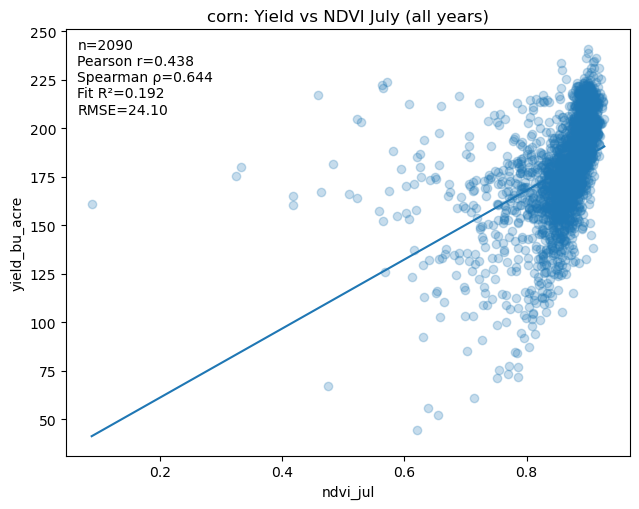

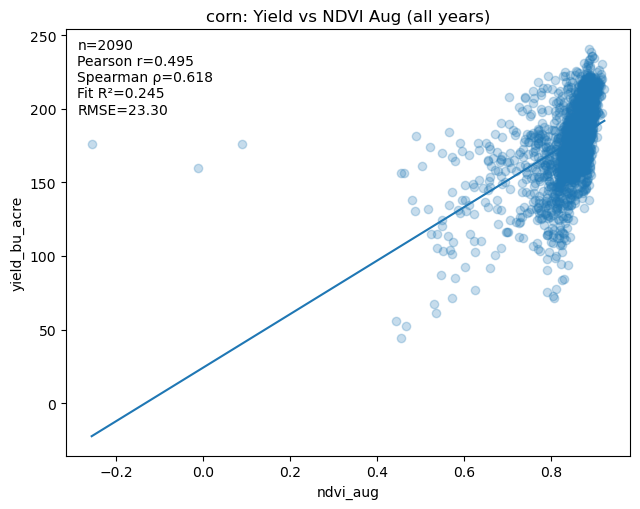

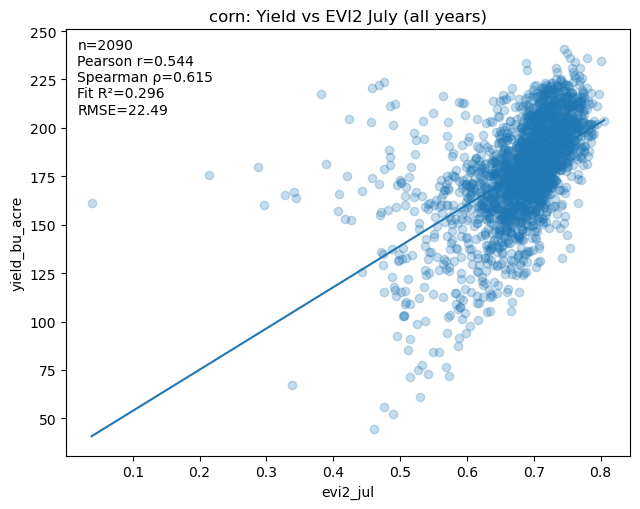

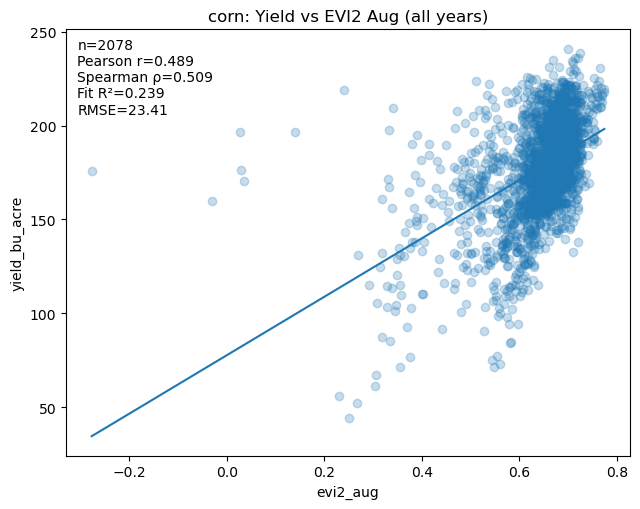

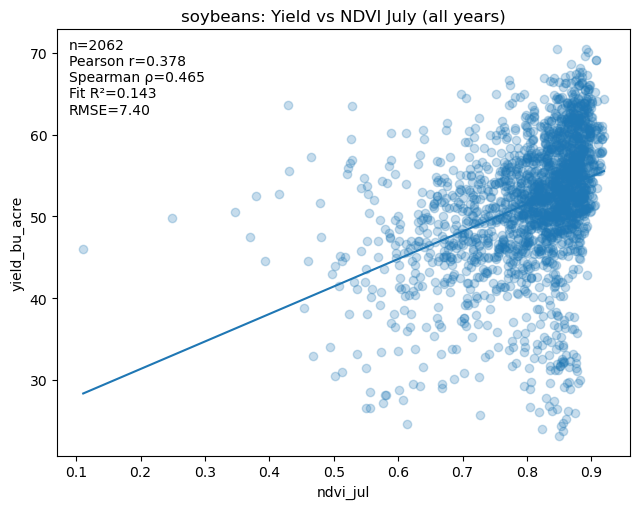

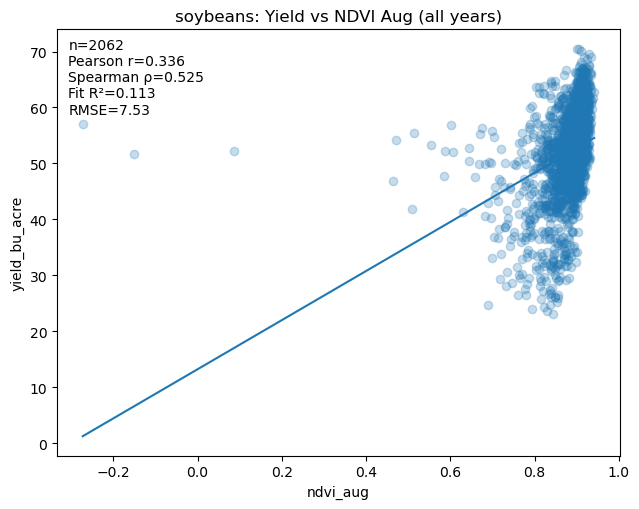

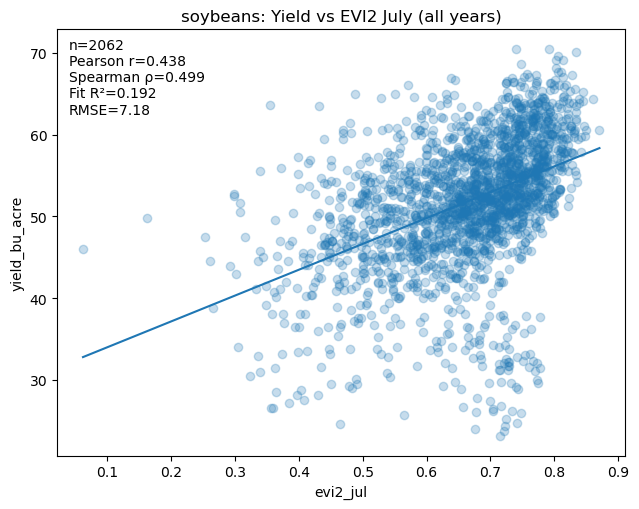

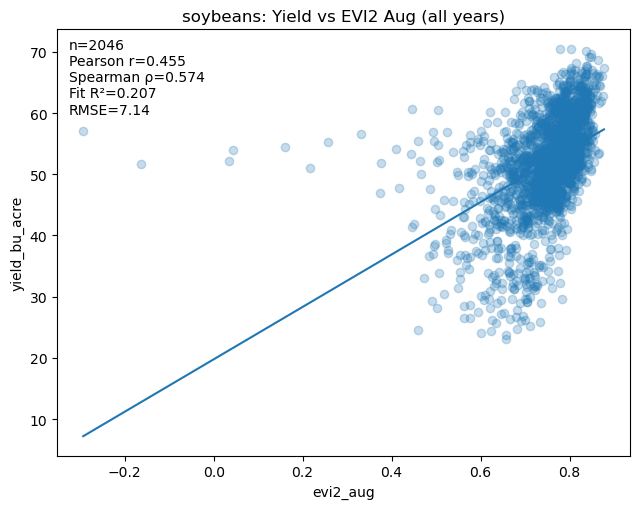

[OK] Wrote metrics → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/yield_vi_tests/metrics_summary_in_sample.csv
[OK] Wrote year-specific correlations → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/yield_vi_tests/correlations_by_year.csv


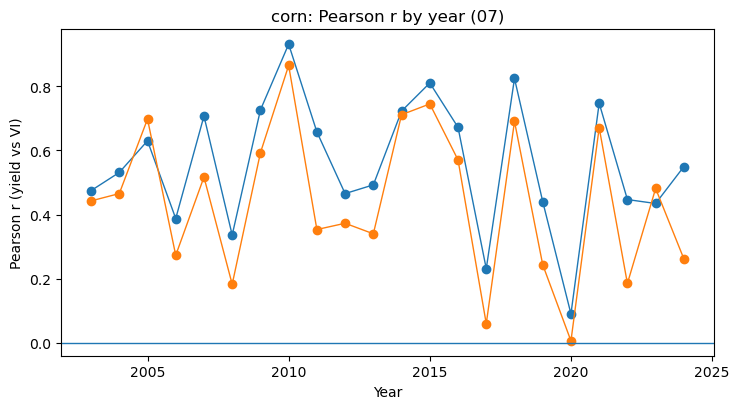

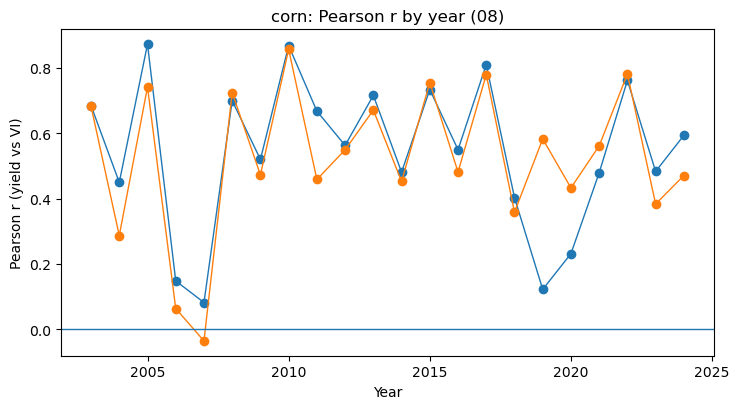

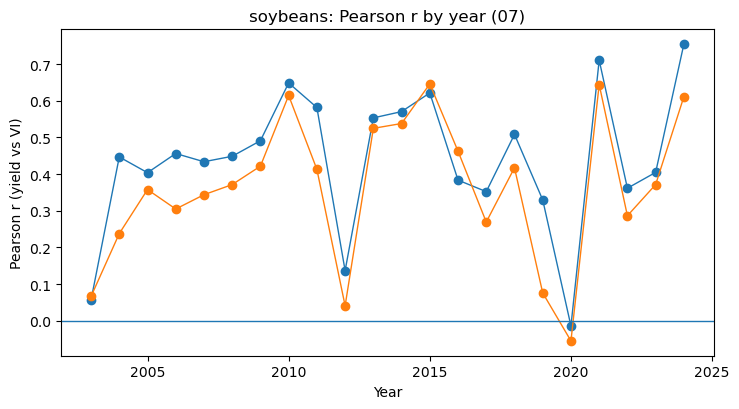

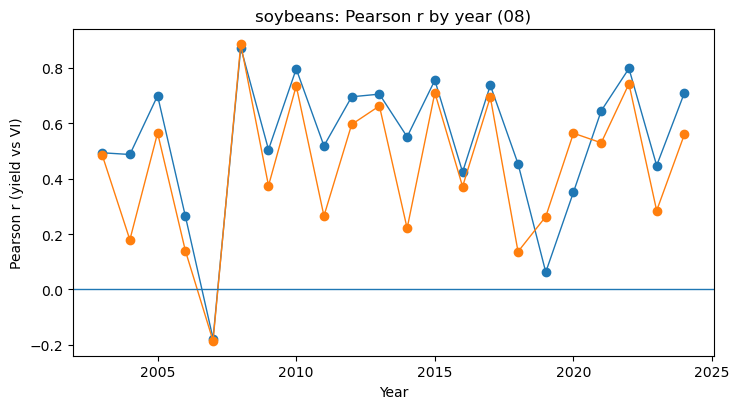


[TOP MODELS by in-sample OLS R²]
    crop        variant                            features    n   ols_R2  ols_RMSE_bu_acre
    corn           All4 ndvi_jul+ndvi_aug+evi2_jul+evi2_aug 2078 0.452391         19.860929
    corn  EVI2_July+Aug                   evi2_jul+evi2_aug 2078 0.399274         20.801885
    corn  NDVI_July+Aug                   ndvi_jul+ndvi_aug 2090 0.362104         21.410436
    corn July_NDVI+EVI2                   ndvi_jul+evi2_jul 2090 0.341977         21.745584
    corn      EVI2_July                            evi2_jul 2090 0.295919         22.493758
soybeans           All4 ndvi_jul+ndvi_aug+evi2_jul+evi2_aug 2046 0.306966          6.674952
soybeans  EVI2_July+Aug                   evi2_jul+evi2_aug 2046 0.298901          6.713679
soybeans  NDVI_July+Aug                   ndvi_jul+ndvi_aug 2062 0.222647          7.045642
soybeans  Aug_NDVI+EVI2                   ndvi_aug+evi2_aug 2046 0.213756          7.109672
soybeans July_NDVI+EVI2                   ndvi

In [13]:
#!/usr/bin/env python3
"""
Option A (no holdout years): Yield–VI relationships.

Outputs:
- metrics_summary_in_sample.csv        (per crop × variant, in-sample OLS + correlations)
- correlations_by_year.csv             (per crop × year × (index,month), correlations)
- plots/scatter_<crop>_<X>.png         (all-years scatter, single-feature variants)
- plots/r_by_year_<crop>_<month>.png   (correlation vs year; NDVI vs EVI2)
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# USER SETTINGS
# -----------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

VI_JULY_DIR = BASE / "analysis" / "vi_by_county_crop_07"
VI_AUG_DIR  = BASE / "analysis" / "vi_by_county_crop_08"

YIELD_DIR = BASE / "Yield_Data"
YIELD_CORN = YIELD_DIR / "yield_corn_iowa_2003_2024_with_fips.csv"  # update if needed
YIELD_SOY  = YIELD_DIR / "yield_soy_iowa_2003_2024_with_fips.csv"   # update if needed

OUT_DIR = BASE / "analysis" / "yield_vi_tests"
PLOT_DIR = OUT_DIR / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MIN_N = 30

# Notebook behavior:
SHOW_PLOTS = True  # set False if running as a pure script and you don't want inline output

# -----------------------------
# Normalization helpers
# -----------------------------
def normalize_county_fips(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace("\u00A0", "", regex=False)
    s = s.str.replace(r"\.0$", "", regex=True)
    s_num = pd.to_numeric(s, errors="coerce")
    out = s_num.astype("Int64").astype(str).str.zfill(5)
    out = out.where(s_num.notna(), pd.NA)
    return out

def normalize_crop(series: pd.Series) -> pd.Series:
    crop_map = {
        "soy": "soybeans", "soybean": "soybeans", "soybeans": "soybeans",
        "corn": "corn", "maize": "corn",
    }
    s = series.astype(str).str.strip().str.lower()
    return s.map(lambda x: crop_map.get(x, x))

# -----------------------------
# Rebuild ALL from per-year files
# -----------------------------
def rebuild_all_from_yearly(folder: Path, month: str) -> Path:
    if not folder.exists():
        raise FileNotFoundError(f"VI folder not found: {folder}")

    pattern = f"vi_by_county_crop_{month}_"
    year_files = sorted(
        p for p in folder.glob(f"{pattern}*.csv")
        if not p.name.endswith("_ALL.csv")
    )
    if not year_files:
        raise FileNotFoundError(f"No per-year VI CSVs found in: {folder}")

    dfs = [pd.read_csv(p) for p in year_files]
    all_df = pd.concat(dfs, ignore_index=True)

    if "year" in all_df.columns:
        all_df["year"] = pd.to_numeric(all_df["year"], errors="coerce").astype("Int64")
    if "county_fips" in all_df.columns:
        all_df["county_fips"] = normalize_county_fips(all_df["county_fips"])
    if "crop" in all_df.columns:
        all_df["crop"] = normalize_crop(all_df["crop"])

    key = [c for c in ["year", "county_fips", "crop"] if c in all_df.columns]
    if key:
        all_df = all_df.drop_duplicates(subset=key).sort_values(key).reset_index(drop=True)

    out_all = folder / f"vi_by_county_crop_{month}_ALL.csv"
    all_df.to_csv(out_all, index=False)

    years = sorted(all_df["year"].dropna().astype(int).unique().tolist()) if "year" in all_df.columns else []
    print(f"[OK] Rebuilt ALL → {out_all}")
    if years:
        print(f"[INFO] Years included ({month}): {years[0]}–{years[-1]} (n={len(years)})")

    return out_all

# -----------------------------
# Read/prep VI + yield
# -----------------------------
def read_vi(all_csv: Path, month_label: str) -> pd.DataFrame:
    df = pd.read_csv(all_csv)

    req = {"year", "county_fips", "crop"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"{all_csv.name} missing {missing}. Has: {list(df.columns)}")

    df = df.copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["county_fips"] = normalize_county_fips(df["county_fips"])
    df["crop"] = normalize_crop(df["crop"])

    rename = {}
    if "mean_ndvi" in df.columns:
        rename["mean_ndvi"] = f"ndvi_{month_label}"
    if "mean_evi2" in df.columns:
        rename["mean_evi2"] = f"evi2_{month_label}"
    df = df.rename(columns=rename)

    keep = ["year", "county_fips", "crop"] + list(rename.values())
    return df[keep]

def read_yield(path: Path, crop_label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing yield file: {path}")

    df = pd.read_csv(path).copy()

    year_col = "year" if "year" in df.columns else ("Year" if "Year" in df.columns else None)
    if year_col is None:
        raise ValueError(f"{path.name} missing year/Year. Columns: {list(df.columns)}")
    df["year"] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

    if "county_fips" in df.columns:
        df["county_fips"] = normalize_county_fips(df["county_fips"])
    elif "FIPS" in df.columns:
        df["county_fips"] = normalize_county_fips(df["FIPS"])
    else:
        raise ValueError(f"{path.name} missing county_fips/FIPS. Columns: {list(df.columns)}")

    cand = [c for c in ["yield_bu_acre", "Yield", "yield", "Value", "VALUE"] if c in df.columns]
    if not cand:
        raise ValueError(f"{path.name} can't find yield column. Columns: {list(df.columns)}")
    ycol = cand[0]
    df["yield_bu_acre"] = pd.to_numeric(df[ycol], errors="coerce")

    if "Geo Level" in df.columns:
        df = df[df["Geo Level"].astype(str).str.upper().eq("COUNTY")].copy()

    df["crop"] = crop_label
    df = df[["year", "county_fips", "crop", "yield_bu_acre"]]
    df = df.groupby(["year", "county_fips", "crop"], as_index=False)["yield_bu_acre"].mean()
    return df

# -----------------------------
# Stats
# -----------------------------
def pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if len(x) < 2:
        return np.nan
    x = x - np.mean(x); y = y - np.mean(y)
    denom = np.sqrt(np.sum(x*x) * np.sum(y*y))
    return np.nan if denom == 0 else float(np.sum(x*y) / denom)

def spearmanr(x, y):
    x = pd.Series(x).rank(method="average").to_numpy()
    y = pd.Series(y).rank(method="average").to_numpy()
    return pearsonr(x, y)

def fit_ols(df: pd.DataFrame, features: list[str], target: str):
    X = df[features].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X = X[ok]; y = y[ok]
    if len(y) < MIN_N:
        return None, np.nan, np.nan
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    yhat = X1 @ beta
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    return beta, float(r2), rmse

# -----------------------------
# Plotting: combined scatter (all years)
# -----------------------------
def scatter_with_trend(df: pd.DataFrame, xcol: str, ycol: str, title: str, outpath: Path):
    d = df[[xcol, ycol]].dropna().copy()
    if len(d) < MIN_N:
        print(f"[SKIP] {title}: n={len(d)} (<{MIN_N})")
        return

    x = d[xcol].to_numpy(dtype=float)
    y = d[ycol].to_numpy(dtype=float)

    A = np.column_stack([np.ones(len(x)), x])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    yhat = A @ beta

    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    r_p = pearsonr(x, y)
    r_s = spearmanr(x, y)

    plt.figure(figsize=(6.5, 5.2))
    plt.scatter(x, y, alpha=0.25)
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ys = beta[0] + beta[1] * xs
    plt.plot(xs, ys)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(title)
    plt.text(
        0.02, 0.98,
        f"n={len(d)}\nPearson r={r_p:.3f}\nSpearman ρ={r_s:.3f}\nFit R²={r2:.3f}\nRMSE={rmse:.2f}",
        transform=plt.gca().transAxes,
        va="top"
    )
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()

# -----------------------------
# Plotting: correlation vs year
# -----------------------------
def plot_r_by_year(corr_df: pd.DataFrame, crop: str, month: str, outpath: Path):
    """
    corr_df expected columns: year, crop, month, index, pearson_r
    """
    d = corr_df[(corr_df["crop"] == crop) & (corr_df["month"] == month)].copy()
    if d.empty:
        return
    # pivot so NDVI/EVI2 are separate series
    pv = d.pivot_table(index="year", columns="index", values="pearson_r", aggfunc="mean").sort_index()

    plt.figure(figsize=(7.5, 4.2))
    for col in pv.columns:
        plt.plot(pv.index, pv[col], marker="o", linewidth=1)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Year")
    plt.ylabel("Pearson r (yield vs VI)")
    plt.title(f"{crop}: Pearson r by year ({month})")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()

# -----------------------------
# MAIN
# -----------------------------
def main():
    # Rebuild ALLs from per-year files (fixes your 2024 overwrite issue)
    july_all = rebuild_all_from_yearly(VI_JULY_DIR, "07")
    aug_all  = rebuild_all_from_yearly(VI_AUG_DIR,  "08")

    # Read VI
    vi7 = read_vi(july_all, "jul")
    vi8 = read_vi(aug_all,  "aug")
    vi = vi7.merge(vi8, on=["year", "county_fips", "crop"], how="inner", validate="one_to_one")

    # Read yields
    ycorn = read_yield(YIELD_CORN, "corn")
    ysoy  = read_yield(YIELD_SOY,  "soybeans")
    yall  = pd.concat([ycorn, ysoy], ignore_index=True)

    # Merge VI with yields
    df = vi.merge(yall, on=["year", "county_fips", "crop"], how="inner")
    df = df.dropna(subset=["yield_bu_acre"]).copy()

    print(f"[INFO] Merged rows: {len(df):,}")
    if len(df) == 0:
        raise SystemExit("[ERROR] 0 merged rows. Check VI folders, yields, and keys.")
    print(f"[INFO] Years in merged: {int(df['year'].min())}–{int(df['year'].max())}")

    # ---------------------------------
    # 1) Combined scatter plots (all years)
    # ---------------------------------
    scatter_specs = [
        ("NDVI_July", "ndvi_jul"),
        ("NDVI_Aug",  "ndvi_aug"),
        ("EVI2_July", "evi2_jul"),
        ("EVI2_Aug",  "evi2_aug"),
    ]
    # Only keep those present
    scatter_specs = [(lab, col) for lab, col in scatter_specs if col in df.columns]

    for crop in ["corn", "soybeans"]:
        d0 = df[df["crop"] == crop].copy()
        for lab, xcol in scatter_specs:
            outpath = PLOT_DIR / f"scatter_{crop}_{lab}.png"
            scatter_with_trend(
                d0,
                xcol,
                "yield_bu_acre",
                title=f"{crop}: Yield vs {lab.replace('_', ' ')} (all years)",
                outpath=outpath
            )

    # ---------------------------------
    # 2) In-sample multivariate comparisons (table)
    # ---------------------------------
    variants = [
        ("NDVI_July",            ["ndvi_jul"]),
        ("NDVI_Aug",             ["ndvi_aug"]),
        ("EVI2_July",            ["evi2_jul"]),
        ("EVI2_Aug",             ["evi2_aug"]),
        ("NDVI_July+Aug",        ["ndvi_jul", "ndvi_aug"]),
        ("EVI2_July+Aug",        ["evi2_jul", "evi2_aug"]),
        ("July_NDVI+EVI2",       ["ndvi_jul", "evi2_jul"]),
        ("Aug_NDVI+EVI2",        ["ndvi_aug", "evi2_aug"]),
        ("All4",                 ["ndvi_jul", "ndvi_aug", "evi2_jul", "evi2_aug"]),
    ]
    variants = [(n, f) for n, f in variants if all(col in df.columns for col in f)]

    metrics_rows = []
    for crop in ["corn", "soybeans"]:
        d0 = df[df["crop"] == crop].copy()
        for name, feats in variants:
            d = d0.dropna(subset=feats + ["yield_bu_acre"]).copy()
            n = len(d)
            if n < MIN_N:
                metrics_rows.append({
                    "crop": crop, "variant": name, "features": "+".join(feats),
                    "n": n, "pearson_r_first_feature": np.nan, "spearman_rho_first_feature": np.nan,
                    "ols_R2": np.nan, "ols_RMSE_bu_acre": np.nan
                })
                continue

            corr_p = pearsonr(d[feats[0]], d["yield_bu_acre"])
            corr_s = spearmanr(d[feats[0]], d["yield_bu_acre"])
            _, r2, rmse = fit_ols(d, feats, "yield_bu_acre")

            metrics_rows.append({
                "crop": crop,
                "variant": name,
                "features": "+".join(feats),
                "n": n,
                "pearson_r_first_feature": corr_p,
                "spearman_rho_first_feature": corr_s,
                "ols_R2": r2,
                "ols_RMSE_bu_acre": rmse,
            })

    metrics = pd.DataFrame(metrics_rows)
    metrics_out = OUT_DIR / "metrics_summary_in_sample.csv"
    metrics.to_csv(metrics_out, index=False)
    print(f"[OK] Wrote metrics → {metrics_out}")

    # ---------------------------------
    # 3) Year-specific correlation table
    # ---------------------------------
    corr_rows = []
    combos = [
        ("NDVI", "07", "ndvi_jul"),
        ("NDVI", "08", "ndvi_aug"),
        ("EVI2", "07", "evi2_jul"),
        ("EVI2", "08", "evi2_aug"),
    ]
    combos = [(idx, mo, col) for (idx, mo, col) in combos if col in df.columns]

    for crop in ["corn", "soybeans"]:
        d0 = df[df["crop"] == crop].copy()
        for (idx, mo, col) in combos:
            for yr, dy in d0.groupby("year"):
                dy2 = dy[[col, "yield_bu_acre"]].dropna()
                n = len(dy2)
                if n < MIN_N:
                    r_p, r_s = np.nan, np.nan
                else:
                    r_p = pearsonr(dy2[col], dy2["yield_bu_acre"])
                    r_s = spearmanr(dy2[col], dy2["yield_bu_acre"])
                corr_rows.append({
                    "crop": crop,
                    "year": int(yr) if pd.notna(yr) else np.nan,
                    "month": mo,
                    "index": idx,
                    "vi_col": col,
                    "n": n,
                    "pearson_r": r_p,
                    "spearman_rho": r_s,
                })

    corr = pd.DataFrame(corr_rows).sort_values(["crop", "index", "month", "year"]).reset_index(drop=True)
    corr_out = OUT_DIR / "correlations_by_year.csv"
    corr.to_csv(corr_out, index=False)
    print(f"[OK] Wrote year-specific correlations → {corr_out}")

    # Optional: plot Pearson r by year (NDVI vs EVI2) for each month
    for crop in ["corn", "soybeans"]:
        for month in ["07", "08"]:
            outpath = PLOT_DIR / f"r_by_year_{crop}_{month}.png"
            plot_r_by_year(corr, crop, month, outpath)

    # Console: top variants by OLS R² (in-sample)
    best = (metrics.dropna(subset=["ols_R2"])
                  .sort_values(["crop", "ols_R2"], ascending=[True, False])
                  .groupby("crop")
                  .head(5))
    print("\n[TOP MODELS by in-sample OLS R²]")
    print(best[["crop", "variant", "features", "n", "ols_R2", "ols_RMSE_bu_acre"]].to_string(index=False))


if __name__ == "__main__":
    main()


[OK] Rebuilt ALL → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_07/vi_by_county_crop_07_ALL.csv
[INFO] Years included (07): 2003–2024 (n=22)
[INFO] Merged rows (July EVI2 + yield): 3,846
[INFO] Years in merged: 2003–2022


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_82569/677210497.py:282: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


[OK] Wrote figure → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/yield_vi_tests/Figure_EVI2_July_Yield_Scatter_and_r_by_year.png
[OK] Wrote r-by-year table → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/yield_vi_tests/pearson_r_by_year_evi2_july.csv


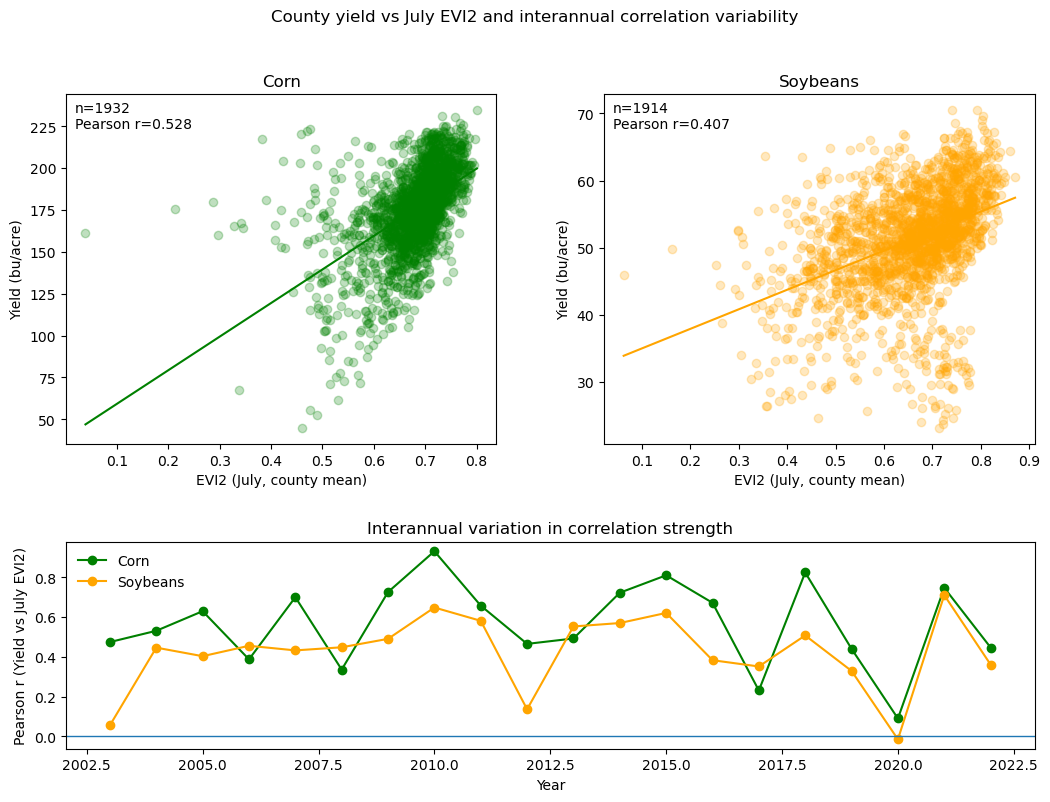

In [14]:
#!/usr/bin/env python3
"""
Multi-panel figure:
- Top row: July EVI2 vs county yield scatter (Corn left, Soy right)
- Bottom row: Pearson r by year for July EVI2 vs yield (Corn + Soy)

Colors:
- Corn: green
- Soy:  orange
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# USER SETTINGS
# -----------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

VI_JULY_DIR = BASE / "analysis" / "vi_by_county_crop_07"
VI_AUG_DIR  = BASE / "analysis" / "vi_by_county_crop_08"  # not used here, but kept for consistency

YIELD_DIR = BASE / "Yield_Data"
YIELD_CORN = YIELD_DIR / "yield_corn_iowa_2000_2022_with_fips.csv"  # update if needed
YIELD_SOY  = YIELD_DIR / "yield_soy_iowa_2000_2022_with_fips.csv"   # update if needed

OUT_DIR = BASE / "analysis" / "yield_vi_tests"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_OUT = OUT_DIR / "Figure_EVI2_July_Yield_Scatter_and_r_by_year.png"

# plot colors (explicitly requested)
CORN_COLOR = "green"
SOY_COLOR  = "orange"

MIN_N_YEAR = 30   # minimum counties required to compute yearly r

# If running in a notebook and you want inline output:
SHOW_FIG = True


# -----------------------------
# Normalization helpers
# -----------------------------
def normalize_county_fips(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace("\u00A0", "", regex=False)
    s = s.str.replace(r"\.0$", "", regex=True)
    s_num = pd.to_numeric(s, errors="coerce")
    out = s_num.astype("Int64").astype(str).str.zfill(5)
    out = out.where(s_num.notna(), pd.NA)
    return out

def normalize_crop(series: pd.Series) -> pd.Series:
    crop_map = {
        "soy": "soybeans", "soybean": "soybeans", "soybeans": "soybeans",
        "corn": "corn", "maize": "corn",
    }
    s = series.astype(str).str.strip().str.lower()
    return s.map(lambda x: crop_map.get(x, x))


# -----------------------------
# Rebuild ALL from per-year VI files (fixes 2024 overwrite issue)
# -----------------------------
def rebuild_all_from_yearly(folder: Path, month: str) -> Path:
    if not folder.exists():
        raise FileNotFoundError(f"VI folder not found: {folder}")

    pattern = f"vi_by_county_crop_{month}_"
    year_files = sorted(
        p for p in folder.glob(f"{pattern}*.csv")
        if not p.name.endswith("_ALL.csv")
    )
    if not year_files:
        raise FileNotFoundError(f"No per-year VI CSVs found in: {folder}")

    dfs = [pd.read_csv(p) for p in year_files]
    all_df = pd.concat(dfs, ignore_index=True)

    if "year" in all_df.columns:
        all_df["year"] = pd.to_numeric(all_df["year"], errors="coerce").astype("Int64")
    if "county_fips" in all_df.columns:
        all_df["county_fips"] = normalize_county_fips(all_df["county_fips"])
    if "crop" in all_df.columns:
        all_df["crop"] = normalize_crop(all_df["crop"])

    key = [c for c in ["year", "county_fips", "crop"] if c in all_df.columns]
    if key:
        all_df = all_df.drop_duplicates(subset=key).sort_values(key).reset_index(drop=True)

    out_all = folder / f"vi_by_county_crop_{month}_ALL.csv"
    all_df.to_csv(out_all, index=False)

    years = sorted(all_df["year"].dropna().astype(int).unique().tolist()) if "year" in all_df.columns else []
    print(f"[OK] Rebuilt ALL → {out_all}")
    if years:
        print(f"[INFO] Years included ({month}): {years[0]}–{years[-1]} (n={len(years)})")

    return out_all


# -----------------------------
# Read/prep VI + yield
# -----------------------------
def read_vi_july_evi2(all_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(all_csv).copy()

    req = {"year", "county_fips", "crop"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"{all_csv.name} missing {missing}. Has: {list(df.columns)}")

    if "mean_evi2" not in df.columns:
        raise ValueError(f"{all_csv.name} has no mean_evi2 column. Columns: {list(df.columns)}")

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["county_fips"] = normalize_county_fips(df["county_fips"])
    df["crop"] = normalize_crop(df["crop"])
    df["evi2_jul"] = pd.to_numeric(df["mean_evi2"], errors="coerce")

    return df[["year", "county_fips", "crop", "evi2_jul"]]

def read_yield(path: Path, crop_label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing yield file: {path}")

    df = pd.read_csv(path).copy()

    year_col = "year" if "year" in df.columns else ("Year" if "Year" in df.columns else None)
    if year_col is None:
        raise ValueError(f"{path.name} missing year/Year. Columns: {list(df.columns)}")
    df["year"] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

    if "county_fips" in df.columns:
        df["county_fips"] = normalize_county_fips(df["county_fips"])
    elif "FIPS" in df.columns:
        df["county_fips"] = normalize_county_fips(df["FIPS"])
    else:
        raise ValueError(f"{path.name} missing county_fips/FIPS. Columns: {list(df.columns)}")

    cand = [c for c in ["yield_bu_acre", "Yield", "yield", "Value", "VALUE"] if c in df.columns]
    if not cand:
        raise ValueError(f"{path.name} can't find yield column. Columns: {list(df.columns)}")
    ycol = cand[0]
    df["yield_bu_acre"] = pd.to_numeric(df[ycol], errors="coerce")

    if "Geo Level" in df.columns:
        df = df[df["Geo Level"].astype(str).str.upper().eq("COUNTY")].copy()

    df["crop"] = crop_label
    df = df[["year", "county_fips", "crop", "yield_bu_acre"]]
    df = df.groupby(["year", "county_fips", "crop"], as_index=False)["yield_bu_acre"].mean()
    return df


# -----------------------------
# Stats helpers
# -----------------------------
def pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if len(x) < 2:
        return np.nan
    x = x - np.mean(x); y = y - np.mean(y)
    denom = np.sqrt(np.sum(x*x) * np.sum(y*y))
    return np.nan if denom == 0 else float(np.sum(x*y) / denom)

def fit_line(x, y):
    """Return intercept, slope for y = a + b x (NaNs removed)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if len(x) < 2:
        return np.nan, np.nan
    A = np.column_stack([np.ones(len(x)), x])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    return float(beta[0]), float(beta[1])


# -----------------------------
# Plot builders
# -----------------------------
def add_scatter_panel(ax, d, crop_name, color):
    x = d["evi2_jul"].to_numpy(dtype=float)
    y = d["yield_bu_acre"].to_numpy(dtype=float)

    ax.scatter(x, y, alpha=0.25, color=color)

    a, b = fit_line(x, y)
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ys = a + b * xs
    ax.plot(xs, ys, color=color)

    r = pearsonr(x, y)
    n = int(np.isfinite(x).sum() if len(x) == len(y) else len(d))
    ax.set_title(crop_name)
    ax.set_xlabel("EVI2 (July, county mean)")
    ax.set_ylabel("Yield (bu/acre)")
    ax.text(0.02, 0.98, f"n={len(d)}\nPearson r={r:.3f}",
            transform=ax.transAxes, va="top")

def add_r_by_year_panel(ax, df_all_years):
    """
    df_all_years columns: year, crop, evi2_jul, yield_bu_acre
    """
    out_rows = []
    for crop in ["corn", "soybeans"]:
        d0 = df_all_years[df_all_years["crop"] == crop].copy()
        for yr, dy in d0.groupby("year"):
            dy2 = dy[["evi2_jul", "yield_bu_acre"]].dropna()
            n = len(dy2)
            if n < MIN_N_YEAR:
                continue
            r = pearsonr(dy2["evi2_jul"], dy2["yield_bu_acre"])
            out_rows.append({"crop": crop, "year": int(yr), "n": n, "r": r})

    corr = pd.DataFrame(out_rows)
    if corr.empty:
        ax.text(0.5, 0.5, "No years meet MIN_N_YEAR for r-by-year", ha="center", va="center")
        return corr

    for crop, color, label in [
        ("corn", CORN_COLOR, "Corn"),
        ("soybeans", SOY_COLOR, "Soybeans"),
    ]:
        dd = corr[corr["crop"] == crop].sort_values("year")
        ax.plot(dd["year"], dd["r"], marker="o", linewidth=1.5, color=color, label=label)

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Year")
    ax.set_ylabel("Pearson r (Yield vs July EVI2)")
    ax.set_title("Interannual variation in correlation strength")
    ax.legend(frameon=False)

    return corr


# -----------------------------
# MAIN
# -----------------------------
def main():
    # Rebuild July ALL to guarantee it contains all years (including separately-run 2024)
    july_all = rebuild_all_from_yearly(VI_JULY_DIR, "07")

    # Load VI (July EVI2 only)
    vi_jul = read_vi_july_evi2(july_all)

    # Load yields
    ycorn = read_yield(YIELD_CORN, "corn")
    ysoy  = read_yield(YIELD_SOY,  "soybeans")
    yall  = pd.concat([ycorn, ysoy], ignore_index=True)

    # Merge
    df = vi_jul.merge(yall, on=["year", "county_fips", "crop"], how="inner")
    df = df.dropna(subset=["evi2_jul", "yield_bu_acre"]).copy()

    print(f"[INFO] Merged rows (July EVI2 + yield): {len(df):,}")
    print(f"[INFO] Years in merged: {int(df['year'].min())}–{int(df['year'].max())}")

    # Split by crop for scatter
    d_corn = df[df["crop"] == "corn"].copy()
    d_soy  = df[df["crop"] == "soybeans"].copy()

    # Figure layout: top row 2 panels, bottom row spans both columns
    fig = plt.figure(figsize=(12.5, 8.5))
    gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[2.2, 1.3], hspace=0.35, wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    add_scatter_panel(ax1, d_corn, "Corn", CORN_COLOR)
    add_scatter_panel(ax2, d_soy,  "Soybeans", SOY_COLOR)

    corr_by_year = add_r_by_year_panel(ax3, df)

    fig.suptitle("County yield vs July EVI2 and interannual correlation variability", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    fig.savefig(FIG_OUT, dpi=300)
    print(f"[OK] Wrote figure → {FIG_OUT}")

    # Also save the r-by-year table (handy for paper + SI)
    if isinstance(corr_by_year, pd.DataFrame) and not corr_by_year.empty:
        corr_out = OUT_DIR / "pearson_r_by_year_evi2_july.csv"
        corr_by_year.to_csv(corr_out, index=False)
        print(f"[OK] Wrote r-by-year table → {corr_out}")

    if SHOW_FIG:
        plt.show()
    else:
        plt.close(fig)


if __name__ == "__main__":
    main()


[OK] Wrote figures → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure S1/Figure_S1_EVI2_July_Yield_CornSoy_kg_ha.png and /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure S1/Figure_S1_EVI2_July_Yield_CornSoy_kg_ha.jpg


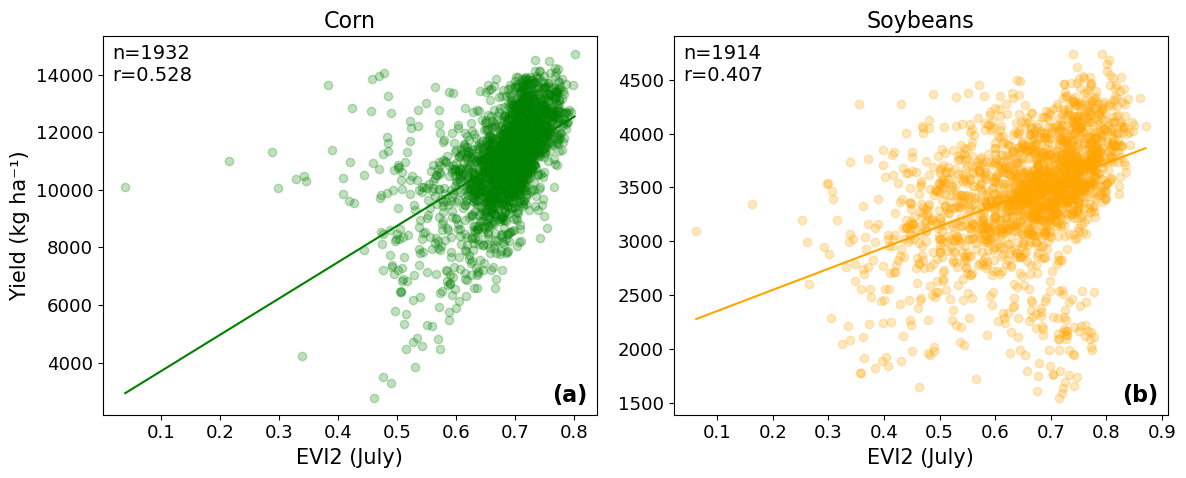

In [26]:
#!/usr/bin/env python3
"""
Main figure (2 panels):
  - Corn (left): July EVI2 vs county yield (kg/ha, all years combined)
  - Soybeans (right): July EVI2 vs county yield (kg/ha, all years combined)

Also produces SI artifacts (not part of main figure):
  - pearson_r_by_year_evi2_july.csv
  - r_by_year_evi2_july.png

Colors:
  - Corn: green
  - Soy:  orange
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# -----------------------------
# Plot style: larger fonts for publication
# -----------------------------
mpl.rcParams.update({
    "font.size": 14,          # base font size
    "axes.titlesize": 16,     # subplot titles
    "axes.labelsize": 15,     # x/y labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
})

# -----------------------------
# USER SETTINGS
# -----------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

VI_JULY_DIR = BASE / "analysis" / "vi_by_county_crop_07"

YIELD_DIR = BASE / "Yield_Data"
YIELD_CORN = YIELD_DIR / "yield_corn_iowa_2000_2022_with_fips.csv"
YIELD_SOY  = YIELD_DIR / "yield_soy_iowa_2000_2022_with_fips.csv"

OUT_DIR = BASE / "analysis" / "yield_vi_tests"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_SI_R_BY_YEAR_OUT = OUT_DIR / "pearson_r_by_year_evi2_july_kg_ha.csv"

# -----------------------------
# Figure output (Supplementary)
# -----------------------------
FIG_DIR = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "Figures/Figure S1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FIG_BASE = FIG_DIR / "Figure_S1_EVI2_July_Yield_CornSoy_kg_ha"
FIG_PNG  = FIG_BASE.with_suffix(".png")
FIG_JPG  = FIG_BASE.with_suffix(".jpg")


CORN_COLOR = "green"
SOY_COLOR  = "orange"

MIN_N_YEAR = 30
SHOW_MAIN_FIG = True

# -----------------------------
# Constants for yield conversion
# -----------------------------
LB_TO_KG = 0.45359237
ACRE_TO_HA = 0.404685642

BU_LB = {
    "corn": 56.0,
    "soybeans": 60.0,
}

# -----------------------------
# Helpers
# -----------------------------
def normalize_county_fips(series):
    s = series.astype(str).str.strip().str.replace("\u00A0", "", regex=False)
    s = s.str.replace(r"\.0$", "", regex=True)
    s_num = pd.to_numeric(s, errors="coerce")
    out = s_num.astype("Int64").astype(str).str.zfill(5)
    return out.where(s_num.notna(), pd.NA)

def normalize_crop(series):
    crop_map = {
        "soy": "soybeans", "soybean": "soybeans", "soybeans": "soybeans",
        "corn": "corn", "maize": "corn",
    }
    return series.astype(str).str.strip().str.lower().map(
        lambda x: crop_map.get(x, x)
    )

# -----------------------------
# Rebuild July ALL file
# -----------------------------
def rebuild_all_from_yearly(folder: Path, month: str) -> Path:
    files = sorted(
        p for p in folder.glob(f"vi_by_county_crop_{month}_*.csv")
        if not p.name.endswith("_ALL.csv")
    )
    dfs = [pd.read_csv(p) for p in files]
    df = pd.concat(dfs, ignore_index=True)

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["county_fips"] = normalize_county_fips(df["county_fips"])
    df["crop"] = normalize_crop(df["crop"])

    df = df.drop_duplicates(subset=["year", "county_fips", "crop"])
    out = folder / f"vi_by_county_crop_{month}_ALL.csv"
    df.to_csv(out, index=False)
    return out

# -----------------------------
# Read July EVI2
# -----------------------------
def read_vi_july(all_csv: Path):
    df = pd.read_csv(all_csv)
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["county_fips"] = normalize_county_fips(df["county_fips"])
    df["crop"] = normalize_crop(df["crop"])
    df["evi2_jul"] = pd.to_numeric(df["mean_evi2"], errors="coerce")
    return df[["year", "county_fips", "crop", "evi2_jul"]]

# -----------------------------
# Read + convert yield
# -----------------------------
def read_yield(path: Path, crop_label: str):
    df = pd.read_csv(path)

    year_col = "year" if "year" in df.columns else "Year"
    df["year"] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

    if "county_fips" in df.columns:
        df["county_fips"] = normalize_county_fips(df["county_fips"])
    else:
        df["county_fips"] = normalize_county_fips(df["FIPS"])

    ycol = next(c for c in ["yield_bu_acre", "Yield", "yield", "Value", "VALUE"] if c in df.columns)
    df["yield_bu_acre"] = pd.to_numeric(df[ycol], errors="coerce")

    # ---- CONVERSION HERE ----
    bu_lb = BU_LB[crop_label]
    df["yield_kg_ha"] = (
        df["yield_bu_acre"]
        * bu_lb
        * LB_TO_KG
        / ACRE_TO_HA
    )

    df["crop"] = crop_label
    df = df[["year", "county_fips", "crop", "yield_kg_ha"]]
    return df.groupby(["year", "county_fips", "crop"], as_index=False).mean()

# -----------------------------
# Stats
# -----------------------------
def pearsonr(x, y):
    x = np.asarray(x); y = np.asarray(y)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    x -= x.mean(); y -= y.mean()
    return np.sum(x*y) / np.sqrt(np.sum(x*x)*np.sum(y*y))

def fit_line(x, y):
    A = np.column_stack([np.ones(len(x)), x])
    b, *_ = np.linalg.lstsq(A, y, rcond=None)
    return b

# -----------------------------
# MAIN
# -----------------------------
def main():
    july_all = rebuild_all_from_yearly(VI_JULY_DIR, "07")
    vi = read_vi_july(july_all)

    ycorn = read_yield(YIELD_CORN, "corn")
    ysoy  = read_yield(YIELD_SOY,  "soybeans")
    yall  = pd.concat([ycorn, ysoy], ignore_index=True)

    df = vi.merge(yall, on=["year", "county_fips", "crop"], how="inner")
    df = df.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)


    for ax, crop, color, label, panel_label in [
        (axes[0], "corn",     CORN_COLOR, "Corn",     "(a)"),
        (axes[1], "soybeans", SOY_COLOR,  "Soybeans", "(b)"),
    ]:
        d = df[df["crop"] == crop]
        x = d["evi2_jul"].to_numpy()
        y = d["yield_kg_ha"].to_numpy()
    
        ax.scatter(x, y, alpha=0.25, color=color)
        b = fit_line(x, y)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, b[0] + b[1]*xs, color=color)
    
        r = pearsonr(x, y)
        ax.set_title(label)
        ax.set_xlabel("EVI2 (July)")
    
        # top-left stats
        ax.text(
            0.02, 0.98,
            f"n={len(d)}\nr={r:.3f}",
            transform=ax.transAxes,
            va="top"
        )
    
        # bottom-right panel label
        ax.text(
            0.98, 0.02,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=16,
            fontweight="bold"
        )

    axes[0].set_ylabel("Yield (kg ha⁻¹)")
    fig.tight_layout()
    fig.savefig(FIG_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(FIG_JPG, dpi=300, bbox_inches="tight")
    print(f"[OK] Wrote figures → {FIG_PNG} and {FIG_JPG}")

    if SHOW_MAIN_FIG:
        plt.show()
    else:
        plt.close(fig)

    # ---- SI: r by year ----
    rows = []
    for crop in ["corn", "soybeans"]:
        for yr, d in df[df["crop"] == crop].groupby("year"):
            if len(d) < MIN_N_YEAR:
                continue
            r = pearsonr(d["evi2_jul"], d["yield_kg_ha"])
            rows.append({"crop": crop, "year": int(yr), "n": len(d), "pearson_r": r})

    pd.DataFrame(rows).to_csv(CSV_SI_R_BY_YEAR_OUT, index=False)

if __name__ == "__main__":
    main()


In [27]:
#!/usr/bin/env python3
"""
Create a metrics_summary-style table (kg/ha yields) for:
- July NDVI, July EVI2
- August NDVI, August EVI2
- July+August combinations

Inputs (VI):
  analysis/vi_by_county_crop_07/vi_by_county_crop_07_YYYY.csv (and/or *_ALL.csv)
  analysis/vi_by_county_crop_08/vi_by_county_crop_08_YYYY.csv (and/or *_ALL.csv)
Expected columns in VI:
  year, county_fips, crop, mean_ndvi, mean_evi2

Inputs (Yield):
  Yield_Data/yield_corn_iowa_..._with_fips.csv
  Yield_Data/yield_soy_iowa_..._with_fips.csv
Expected columns:
  year/Year, county_fips or FIPS, plus yield column (Value/Yield/etc) in bu/acre

Output:
  analysis/yield_vi_tests/metrics_summary_kg_ha.csv
"""

from pathlib import Path
import numpy as np
import pandas as pd
import os

# -----------------------------
# USER SETTINGS
# -----------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

VI_JULY_DIR = BASE / "analysis" / "vi_by_county_crop_07"
VI_AUG_DIR  = BASE / "analysis" / "vi_by_county_crop_08"

YIELD_DIR  = BASE / "Yield_Data"
YIELD_CORN = YIELD_DIR / "yield_corn_iowa_2000_2022_with_fips.csv"   # update if needed
YIELD_SOY  = YIELD_DIR / "yield_soy_iowa_2000_2022_with_fips.csv"    # update if needed

OUT_DIR = BASE / "analysis" / "yield_vi_tests"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / "metrics_summary_kg_ha.csv"

MIN_N = 30  # minimum points per crop/variant

# -----------------------------
# Constants for yield conversion
# -----------------------------
LB_TO_KG = 0.45359237
ACRE_TO_HA = 0.404685642
BU_LB = {"corn": 56.0, "soybeans": 60.0}

# -----------------------------
# Helpers
# -----------------------------
def normalize_county_fips(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace("\u00A0", "", regex=False)
    s = s.str.replace(r"\.0$", "", regex=True)
    s_num = pd.to_numeric(s, errors="coerce")
    out = s_num.astype("Int64").astype(str).str.zfill(5)
    return out.where(s_num.notna(), pd.NA)

def normalize_crop(series: pd.Series) -> pd.Series:
    crop_map = {
        "soy": "soybeans", "soybean": "soybeans", "soybeans": "soybeans",
        "corn": "corn", "maize": "corn",
    }
    return series.astype(str).str.strip().str.lower().map(lambda x: crop_map.get(x, x))

def pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if len(x) < 2:
        return np.nan
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt(np.sum(x*x) * np.sum(y*y))
    return np.nan if denom == 0 else float(np.sum(x*y) / denom)

def spearmanr(x, y):
    xr = pd.Series(x).rank(method="average").to_numpy()
    yr = pd.Series(y).rank(method="average").to_numpy()
    return pearsonr(xr, yr)

def r2_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[ok]; y_pred = y_pred[ok]
    if len(y_true) < 2:
        return np.nan, np.nan
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return float(r2), float(rmse)

def rebuild_all_from_yearly(folder: Path, month: str) -> Path:
    if not folder.exists():
        raise FileNotFoundError(f"VI folder not found: {folder}")

    year_files = sorted(
        p for p in folder.glob(f"vi_by_county_crop_{month}_*.csv")
        if not p.name.endswith("_ALL.csv")
    )
    if not year_files:
        raise FileNotFoundError(f"No per-year VI CSVs found in: {folder}")

    dfs = [pd.read_csv(p) for p in year_files]
    df = pd.concat(dfs, ignore_index=True)

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["county_fips"] = normalize_county_fips(df["county_fips"])
    df["crop"] = normalize_crop(df["crop"])

    df = df.drop_duplicates(subset=["year", "county_fips", "crop"])
    out = folder / f"vi_by_county_crop_{month}_ALL.csv"
    df.to_csv(out, index=False)

    yrs = sorted(df["year"].dropna().astype(int).unique().tolist())
    print(f"[OK] Rebuilt ALL → {out}")
    print(f"[INFO] Years included ({month}): {yrs[0]}–{yrs[-1]} (n={len(yrs)})")
    return out

def read_vi(all_csv: Path, month_label: str) -> pd.DataFrame:
    df = pd.read_csv(all_csv).copy()

    req = {"year", "county_fips", "crop", "mean_ndvi", "mean_evi2"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"{all_csv.name} missing {missing}. Has: {list(df.columns)}")

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["county_fips"] = normalize_county_fips(df["county_fips"])
    df["crop"] = normalize_crop(df["crop"])

    df[f"ndvi_{month_label}"] = pd.to_numeric(df["mean_ndvi"], errors="coerce")
    df[f"evi2_{month_label}"] = pd.to_numeric(df["mean_evi2"], errors="coerce")

    return df[["year", "county_fips", "crop", f"ndvi_{month_label}", f"evi2_{month_label}"]]

def read_yield_kg_ha(path: Path, crop_label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing yield file: {path}")

    df = pd.read_csv(path).copy()

    year_col = "year" if "year" in df.columns else ("Year" if "Year" in df.columns else None)
    if year_col is None:
        raise ValueError(f"{path.name} missing year/Year. Columns: {list(df.columns)}")
    df["year"] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

    if "county_fips" in df.columns:
        df["county_fips"] = normalize_county_fips(df["county_fips"])
    elif "FIPS" in df.columns:
        df["county_fips"] = normalize_county_fips(df["FIPS"])
    else:
        raise ValueError(f"{path.name} missing county_fips/FIPS. Columns: {list(df.columns)}")

    ycol_candidates = ["yield_bu_acre", "Yield", "yield", "Value", "VALUE"]
    ycol = next((c for c in ycol_candidates if c in df.columns), None)
    if ycol is None:
        raise ValueError(f"{path.name} can't find yield column. Columns: {list(df.columns)}")
    df["yield_bu_acre"] = pd.to_numeric(df[ycol], errors="coerce")

    bu_lb = BU_LB[crop_label]
    df["yield_kg_ha"] = df["yield_bu_acre"] * bu_lb * LB_TO_KG / ACRE_TO_HA

    df["crop"] = crop_label
    df = df[["year", "county_fips", "crop", "yield_kg_ha"]]
    df = df.groupby(["year", "county_fips", "crop"], as_index=False)["yield_kg_ha"].mean()
    return df

def fit_ols(df: pd.DataFrame, features: list[str], ycol: str = "yield_kg_ha"):
    d = df[features + [ycol]].dropna()
    if len(d) < MIN_N:
        return None

    X = d[features].to_numpy(dtype=float)
    y = d[ycol].to_numpy(dtype=float)

    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    yhat = X1 @ beta
    r2, rmse = r2_rmse(y, yhat)

    return {
        "n": int(len(d)),
        "intercept": float(beta[0]),
        **{f"slope_{f}": float(beta[i+1]) for i, f in enumerate(features)},
        "r2_in_sample": r2,
        "rmse_kg_ha_in_sample": rmse,
    }

# -----------------------------
# MAIN
# -----------------------------
def main():
    # Rebuild ALL files (prevents the “ALL now only has 2024” issue)
    july_all = rebuild_all_from_yearly(VI_JULY_DIR, "07")
    aug_all  = rebuild_all_from_yearly(VI_AUG_DIR,  "08")

    vi_jul = read_vi(july_all, "jul")
    vi_aug = read_vi(aug_all,  "aug")

    # Merge July+Aug into one wide VI table (one row per county-year-crop)
    vi = vi_jul.merge(vi_aug, on=["year", "county_fips", "crop"], how="inner", validate="one_to_one")

    # Yield (kg/ha)
    ycorn = read_yield_kg_ha(YIELD_CORN, "corn")
    ysoy  = read_yield_kg_ha(YIELD_SOY,  "soybeans")
    yall  = pd.concat([ycorn, ysoy], ignore_index=True)

    # Merge VI with yield
    df = vi.merge(yall, on=["year", "county_fips", "crop"], how="inner")
    df = df.dropna(subset=["yield_kg_ha"]).copy()

    print(f"[INFO] Merged rows: {len(df):,}")
    print(f"[INFO] Years: {int(df['year'].min())}–{int(df['year'].max())}")

    variants = [
        ("NDVI_July",       ["ndvi_jul"]),
        ("EVI2_July",       ["evi2_jul"]),
        ("NDVI_Aug",        ["ndvi_aug"]),
        ("EVI2_Aug",        ["evi2_aug"]),
        ("NDVI_July+Aug",   ["ndvi_jul", "ndvi_aug"]),
        ("EVI2_July+Aug",   ["evi2_jul", "evi2_aug"]),
        ("July_NDVI+EVI2",  ["ndvi_jul", "evi2_jul"]),
        ("Aug_NDVI+EVI2",   ["ndvi_aug", "evi2_aug"]),
        ("All4",            ["ndvi_jul", "ndvi_aug", "evi2_jul", "evi2_aug"]),
    ]

    rows = []
    for crop in ["corn", "soybeans"]:
        d0 = df[df["crop"] == crop].copy()

        for name, feats in variants:
            # Single-feature correlation metrics
            if len(feats) == 1:
                d_corr = d0[[feats[0], "yield_kg_ha"]].dropna()
                if len(d_corr) >= MIN_N:
                    r_p = pearsonr(d_corr[feats[0]], d_corr["yield_kg_ha"])
                    r_s = spearmanr(d_corr[feats[0]], d_corr["yield_kg_ha"])
                    n_corr = int(len(d_corr))
                else:
                    r_p, r_s, n_corr = np.nan, np.nan, int(len(d_corr))
            else:
                r_p, r_s, n_corr = np.nan, np.nan, 0

            fit = fit_ols(d0, feats, ycol="yield_kg_ha")
            if fit is None:
                fit = {"n": 0, "intercept": np.nan, "r2_in_sample": np.nan, "rmse_kg_ha_in_sample": np.nan}
                for f in feats:
                    fit[f"slope_{f}"] = np.nan

            rows.append({
                "crop": crop,
                "variant": name,
                "features": "+".join(feats),
                "n_corr_single_feature": n_corr if len(feats) == 1 else np.nan,
                "pearson_r_single_feature": r_p,
                "spearman_rho_single_feature": r_s,
                "n_fit": fit["n"],
                "intercept": fit["intercept"],
                **{k: v for k, v in fit.items() if k.startswith("slope_")},
                "r2_in_sample": fit["r2_in_sample"],
                "rmse_kg_ha_in_sample": fit["rmse_kg_ha_in_sample"],
            })

    out = pd.DataFrame(rows)
    out.to_csv(OUT_CSV, index=False)
    print(f"[OK] Wrote metrics summary (kg/ha) → {OUT_CSV}")

if __name__ == "__main__":
    main()


[OK] Rebuilt ALL → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_07/vi_by_county_crop_07_ALL.csv
[INFO] Years included (07): 2003–2024 (n=22)
[OK] Rebuilt ALL → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/vi_by_county_crop_08/vi_by_county_crop_08_ALL.csv
[INFO] Years included (08): 2003–2024 (n=22)
[INFO] Merged rows: 3,842
[INFO] Years: 2003–2022
[OK] Wrote metrics summary (kg/ha) → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/yield_vi_tests/metrics_summary_kg_ha.csv
